Combinazioni di regressioni

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression, LinearRegression


In [4]:
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name='target')

X.head()
y.describe()

count    569.000000
mean       0.627417
std        0.483918
min        0.000000
25%        0.000000
50%        1.000000
75%        1.000000
max        1.000000
Name: target, dtype: float64

In [6]:
# selezioniamo solo una feature. sappiamo già che quella più importante è la prima, mean radius
X_sel = X[['mean radius']]

print(X_sel.shape)

# proviamo ad applicare la regressione lineare alla feature e vediamo cosa succede

lin_reg = LinearRegression()
lin_reg.fit(X_sel, y)

y_lin = lin_reg.predict(X_sel)

(569, 1)


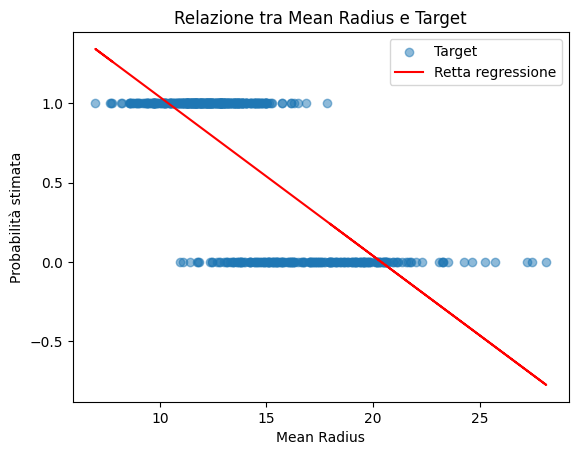

In [7]:
plt.scatter(X_sel, y, alpha=0.5, label='Target')
plt.plot(X_sel, y_lin, color='red', label='Retta regressione')
plt.xlabel('Mean Radius')
plt.ylabel("Probabilità stimata")
plt.title('Relazione tra Mean Radius e Target')
plt.legend()
plt.show()

In [ ]:
# creazione del nuovo dataset dove applichiamo la regressione lineare alla feature creata

X_new = X.copy()
X_new["lin_pred"] = y_lin

log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_new, y)

y_pred = log_reg.predict(X_new)

accuracy = np.mean(y_pred == y)
print(f"Accuracy: {accuracy*100:.2f}%")

# il terminal ci dà un avviso: dopo 1.000 iterazioni, il modello non è ancora arrivato a convergenza
# abbiamo due soluzioni: aumentiamo il numero di iterazioni, oppure scaliamo i dati 


Accuracy: 96.13%


c:\Users\chian\Desktop\Programmi Python\Modulo-3\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
# Opzione 1 - scalare i dati

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_new)
log_reg_scaled = LogisticRegression(max_iter=1000, random_state=42)
log_reg_scaled.fit(X_scaled, y)

y_pred_scaled = log_reg_scaled.predict(X_scaled)

accuracy_scaled = np.mean(y_pred_scaled == y)
print(f"Accuracy dopo scaling: {accuracy_scaled*100:.2f}%")

# dai risultati vediamo che l'accuracy è migliorata e abbiamo anche risolto il problema del numero di iterazioni

Accuracy dopo scaling: 98.77%


In [12]:
print(log_reg_scaled.n_iter_)

# siamo passati che non erano sufficienti 1.000 iterazioni a 18 iterazioni sufficienti per convergere

[18]


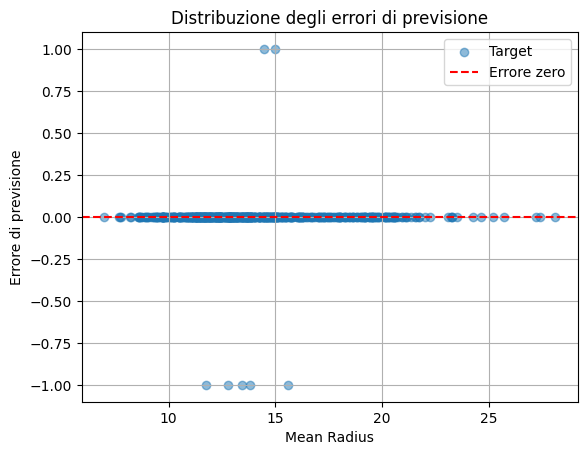

In [15]:
# scatter plot della distribuzione degli errori

plt.scatter(X_sel, y - y_pred_scaled, alpha=0.5, label='Target')
plt.axhline(0, color='red', linestyle='--', label='Errore zero')
plt.xlabel('Mean Radius')
plt.ylabel("Errore di previsione")
plt.title('Distribuzione degli errori di previsione')
plt.legend()
plt.grid(0.5)
plt.show()

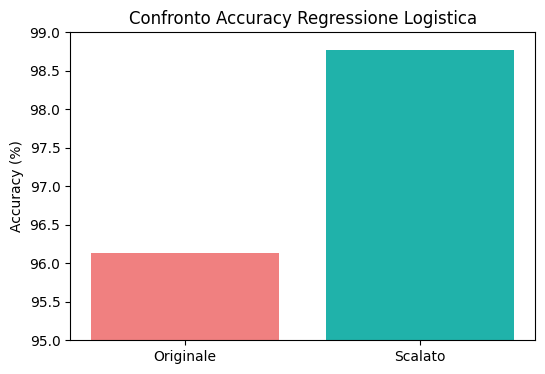

In [16]:
# grafico a barre della differenza della regressione logistica con e senza scaling

plt.figure(figsize=(6, 4))
plt.bar(
    ["Originale", "Scalato"],
    [accuracy*100, accuracy_scaled*100],
    color= ["lightcoral", "lightseagreen"]
)
plt.ylabel("Accuracy (%)")
plt.title("Confronto Accuracy Regressione Logistica")
plt.ylim(95, 99)    # la limitiamo per vedere meglio la differenza
plt.show()